In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('default')
%matplotlib inline

In [2]:
Uber_df = pd.read_csv("ncr_ride_bookings.csv")

In [3]:
Uber_df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [4]:
Uber_df.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [5]:
Uber_df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [6]:
Uber_df.isna().sum().sum()

1123500

<AxesSubplot:>

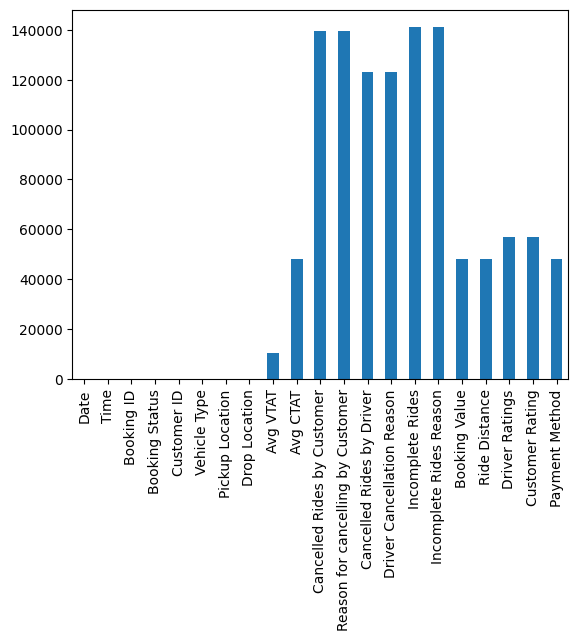

In [7]:
Uber_df.isna().sum().plot(kind='bar')

In [8]:
# Calculate total and percentage of missing values per column
missing_data = pd.concat([
    Uber_df.isnull().sum(),
    Uber_df.isnull().mean() * 100,
    Uber_df.dtypes
], axis=1)

# Rename columns for clarity
missing_data.columns = ['Total', 'Percentage_of_missing_data', 'Types']

# Sort by highest missing percentage
missing_data = missing_data.sort_values(
    by='Percentage_of_missing_data', ascending=False
)

missing_data

,Total,Percentage_of_missing_data,Types
Incomplete Rides Reason,141000,94.0,object
Incomplete Rides,141000,94.0,float64
Cancelled Rides by Customer,139500,93.0,float64
Reason for cancelling by Customer,139500,93.0,object
Driver Cancellation Reason,123000,82.0,object
Cancelled Rides by Driver,123000,82.0,float64
Customer Rating,57000,38.0,float64
Driver Ratings,57000,38.0,float64
Ride Distance,48000,32.0,float64
Booking Value,48000,32.0,float64


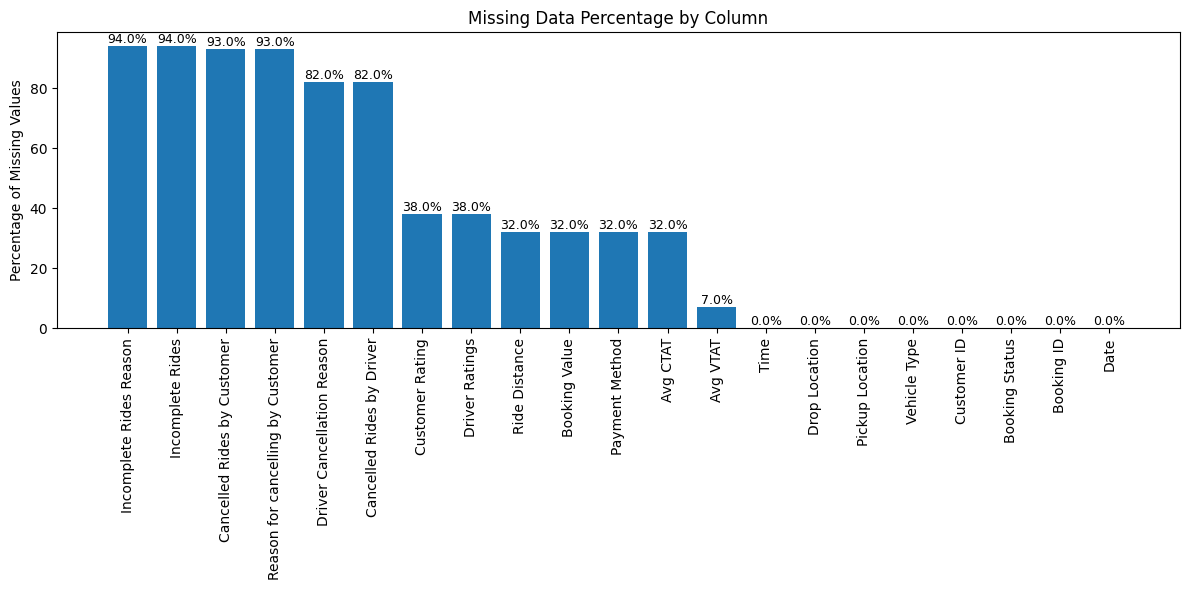

In [9]:
# Visualize percentage of missing data
plt.figure(figsize=(12, 6))

bars = plt.bar(
    missing_data.index,
    missing_data['Percentage_of_missing_data']
)

plt.xticks(rotation=90)
plt.ylabel("Percentage of Missing Values")
plt.title("Missing Data Percentage by Column")

# Annotate percentages on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()


In [10]:
Uber_df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [11]:
Uber_df.duplicated().sum()

0

In [12]:
status_counts = Uber_df['Booking Status'].value_counts()
status_counts

Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: Booking Status, dtype: int64

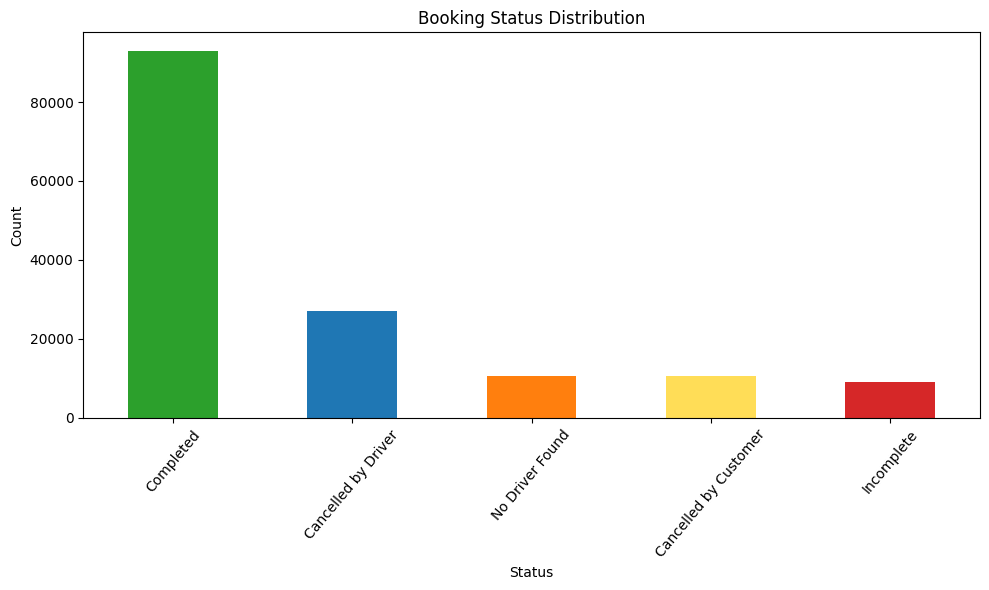

In [13]:
plt.figure(figsize=(10, 6))
status_counts.plot(kind='bar', color=['#2ca02c', '#1f77b4', '#ff7f0e', '#ffdd57', '#d62728'])
plt.title('Booking Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

## Data cleaning

In [14]:
Uber_clean = Uber_df.copy()

In [15]:
high_num_missing = missing_data[
    (missing_data['Percentage_of_missing_data'] >= 80) &
    (missing_data['Types'] == 'float64')
].index.tolist()

In [16]:
high_num_missing

['Incomplete Rides',
 'Cancelled Rides by Customer',
 'Cancelled Rides by Driver']

In [17]:
high_num_missing=['Incomplete Rides','Cancelled Rides by Customer','Cancelled Rides by Driver']
for col in high_num_missing:
    Uber_clean[col]=Uber_clean[col].apply (lambda x: 1 if pd.notna(x) else 0)

In [18]:
high_cat_missing = missing_data[
    (missing_data['Percentage_of_missing_data'] >= 80) &
    (missing_data['Types'] == 'object')
].index.tolist()

In [19]:
high_cat_missing

['Incomplete Rides Reason',
 'Reason for cancelling by Customer',
 'Driver Cancellation Reason']

In [20]:
high_cat_missing = ['Incomplete Rides Reason','Reason for cancelling by Customer','Driver Cancellation Reason']

for col in high_cat_missing:
    Uber_clean[col] = np.where(
        Uber_clean['Booking Status'] == 'Completed',  
        'Completed Ride',   
        Uber_clean[col].fillna('Unknown'))

In [21]:
moderate_num_missing = missing_data[
    missing_data.apply(
        lambda row: 30 <= row['Percentage_of_missing_data'] < 70 and row['Types'] == 'float64',
        axis=1
    )
].index.tolist()

In [22]:
moderate_num_missing

['Customer Rating',
 'Driver Ratings',
 'Ride Distance',
 'Booking Value',
 'Avg CTAT']

In [23]:
moderate_num_missing=['Customer Rating','Driver Ratings','Ride Distance','Booking Value','Avg CTAT']
for col in moderate_num_missing:
    Uber_clean[col] = Uber_clean[col].fillna(Uber_clean[col].median())

In [24]:
moderate_cat_missing = missing_data[
    missing_data.apply(
        lambda row: 30 <= row['Percentage_of_missing_data'] < 70 and row['Types'] == 'object',
        axis=1
    )
].index.tolist()

In [25]:
moderate_cat_missing

['Payment Method']

In [26]:
moderate_cat_missing=['Payment Method']
for col in moderate_cat_missing:
    Uber_clean[col] = Uber_clean[col].fillna(Uber_clean[col].mode()[0])

In [27]:
Uber_clean['Avg VTAT'].fillna(Uber_clean['Avg VTAT'].median(),inplace=True)

In [28]:
# Check if we have any null values
Uber_clean.isnull().sum().sum()

0

In [29]:
# Uber_clean

In [30]:
quotes_columns = []

for col in Uber_clean.columns: # seraching for every col in the Uber_cleaned
    if Uber_clean[col].dtype == 'object': # Selecting only string columns
        if Uber_clean[col].str.contains('"').any(): # check for any quotes in the data
            quotes_columns.append(col) # append columns with quotes in the list

print("Columns that contain quotes:")
print(quotes_columns)

Columns that contain quotes:
['Booking ID', 'Customer ID']


In [31]:
for col in quotes_columns:
    if col in Uber_clean.columns:
        Uber_clean[col] = Uber_clean[col].str.replace('"', '')

In [32]:
Uber_clean

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,8.3,28.8,...,Unknown,0,Unknown,0,Unknown,414.0,23.72,4.3,4.5,UPI
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,Unknown,0,Unknown,1,Vehicle Breakdown,237.0,5.73,4.3,4.5,UPI
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Completed Ride,0,Completed Ride,0,Completed Ride,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Completed Ride,0,Completed Ride,0,Completed Ride,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Completed Ride,0,Completed Ride,0,Completed Ride,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,Completed Ride,0,Completed Ride,0,Completed Ride,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,Completed Ride,0,Completed Ride,0,Completed Ride,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,Completed Ride,0,Completed Ride,0,Completed Ride,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,Completed Ride,0,Completed Ride,0,Completed Ride,333.0,45.54,4.1,3.7,UPI


In [33]:
# We noticed the date & time columns are string so it's best to convert it to DateTime and merge it together 
Uber_clean['DateTime']= pd.to_datetime(Uber_clean['Date'] + ' ' + Uber_clean['Time'])

In [34]:
Uber_clean[['DateTime']]

,DateTime
0,2024-03-23 12:29:38
1,2024-11-29 18:01:39
2,2024-08-23 08:56:10
3,2024-10-21 17:17:25
4,2024-09-16 22:08:00
...,...
149995,2024-11-11 19:34:01
149996,2024-11-24 15:55:09
149997,2024-09-18 10:55:15
149998,2024-10-05 07:53:34


### for better analysis we need to calculate Hour, DayOfWeek, Month

In [35]:
Uber_clean['Hour'] = Uber_clean['DateTime'].dt.hour
Uber_clean['DayOfWeek'] = Uber_clean['DateTime'].dt.day_name()
Uber_clean['Month'] = Uber_clean['DateTime'].dt.month_name()

In [36]:
Uber_clean

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime,Hour,DayOfWeek,Month
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,8.3,28.8,...,Unknown,414.0,23.72,4.3,4.5,UPI,2024-03-23 12:29:38,12,Saturday,March
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,Vehicle Breakdown,237.0,5.73,4.3,4.5,UPI,2024-11-29 18:01:39,18,Friday,November
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Completed Ride,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,August
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,Completed Ride,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,October
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,Completed Ride,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,Completed Ride,475.0,40.08,3.7,4.1,Uber Wallet,2024-11-11 19:34:01,19,Monday,November
149996,2024-11-24,15:55:09,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,Completed Ride,1093.0,21.31,4.8,5.0,UPI,2024-11-24 15:55:09,15,Sunday,November
149997,2024-09-18,10:55:15,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,Completed Ride,852.0,15.93,3.9,4.4,Cash,2024-09-18 10:55:15,10,Wednesday,September
149998,2024-10-05,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,Completed Ride,333.0,45.54,4.1,3.7,UPI,2024-10-05 07:53:34,7,Saturday,October


In [37]:
def peak_hour(Hour):
    if Hour > 7 and Hour < 10:
        return 1
    elif Hour > 17 and Hour < 21:
        return 1
    else: 
        return 0

In [38]:
Uber_clean['Peak_hour']=Uber_clean['Hour'].apply(peak_hour)

In [39]:
Uber_clean['Peak_Hour_Label'] = Uber_clean['Peak_hour'].map({1: "Peak", 0: "Non-Peak"})

In [40]:
def time_of_day(hour):
    if hour >= 6 and hour < 12:
        return "Morning"
    if hour > 12 and hour < 17:
        return "Afternoon"
    if hour >= 17 and hour < 21:
        return "Evening"
    else:
        return "Night"

In [41]:
Uber_clean['Time_of_Day']=Uber_clean['Hour'].apply(time_of_day)

In [42]:
Uber_clean['Time_of_Day'].value_counts()

Evening      44118
Morning      42672
Night        32874
Afternoon    30336
Name: Time_of_Day, dtype: int64

In [43]:
Uber_clean

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Driver Ratings,Customer Rating,Payment Method,DateTime,Hour,DayOfWeek,Month,Peak_hour,Peak_Hour_Label,Time_of_Day
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,8.3,28.8,...,4.3,4.5,UPI,2024-03-23 12:29:38,12,Saturday,March,0,Non-Peak,Night
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,4.3,4.5,UPI,2024-11-29 18:01:39,18,Friday,November,1,Peak,Evening
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,August,1,Peak,Morning
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,October,0,Non-Peak,Evening
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,September,0,Non-Peak,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,CNR6500631,Completed,CID4337371,Go Mini,MG Road,Ghitorni,10.2,44.4,...,3.7,4.1,Uber Wallet,2024-11-11 19:34:01,19,Monday,November,1,Peak,Evening
149996,2024-11-24,15:55:09,CNR2468611,Completed,CID2325623,Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,4.8,5.0,UPI,2024-11-24 15:55:09,15,Sunday,November,0,Non-Peak,Afternoon
149997,2024-09-18,10:55:15,CNR6358306,Completed,CID9925486,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,3.9,4.4,Cash,2024-09-18 10:55:15,10,Wednesday,September,0,Non-Peak,Morning
149998,2024-10-05,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,4.1,3.7,UPI,2024-10-05 07:53:34,7,Saturday,October,0,Non-Peak,Morning


In [44]:
inr_to_sar = 0.045 

In [45]:
Uber_clean['Booking Value'] = Uber_clean['Booking Value'] * inr_to_sar

In [46]:
Uber_clean.rename(columns={'Booking Value': 'Booking Value SAR'}, inplace=True)

## Ride Status Analysis (Completed vs Cancelled vs Incomplete)

In [47]:
total_rides = Uber_clean['Booking ID'].count()
print(f"Number of Rides: {total_rides}")

rides_completed = (Uber_clean['Booking Status'].str.strip() == "Completed").sum()
print(f"Number of Rides Completed: {rides_completed}")

Number of Rides: 150000
Number of Rides Completed: 93000


In [48]:
Rate_of_completed_rides=rides_completed*100/total_rides
print(f"Rate_of_percent_completed rides :{Rate_of_completed_rides}%")

Rate_of_percent_completed rides :62.0%


In [49]:
incompleted_rides=total_rides- ((Uber_clean['Booking Status'].str.strip()=='Completed').sum())
print(f"Number of Rides Incompleted: {incompleted_rides}")

Number of Rides Incompleted: 57000


In [50]:
Rate_of_incompleted_rides=incompleted_rides*100/total_rides
print(f"Rate_of_percent_completed rides :{Rate_of_incompleted_rides}%")

Rate_of_percent_completed rides :38.0%


In [51]:
cancellation_ride=((Uber_clean['Booking Status'].str.strip()=='Cancelled by Driver').sum()
                                 +(Uber_clean['Booking Status'].str.strip()=='Cancelled by Customer').sum())
print(f"Number of Rides Cancelled: {cancellation_ride}")

Number of Rides Cancelled: 37500


In [52]:
Rate_of_cancellation_rides=cancellation_ride*100/total_rides
print(f"Rate_of_percent_cancelled rides :{Rate_of_cancellation_rides}%")

Rate_of_percent_cancelled rides :25.0%


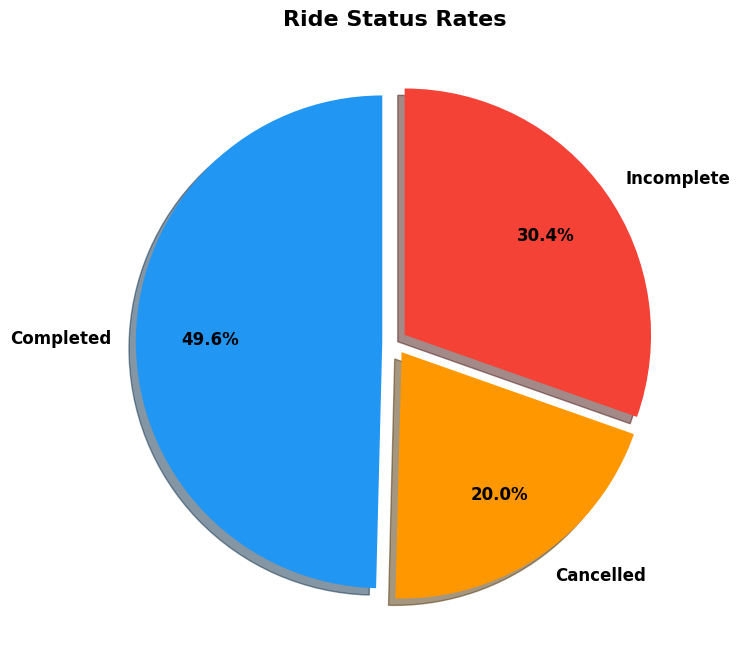

In [53]:
labels = ["Completed", "Cancelled", "Incomplete"]
values = [Rate_of_completed_rides, Rate_of_cancellation_rides, Rate_of_incompleted_rides]
colors = ['#2196F3', '#FF9800', '#F44336']
explode = (0.05, 0.05, 0.05)  

plt.figure(figsize=(8,8))
wedges, texts, autotexts = plt.pie(
    values, 
    labels=labels, 
    colors=colors, 
    startangle=90, 
    autopct='%1.1f%%',  
    pctdistance=0.7,     
    explode=explode,
    shadow=True
)

for text in texts + autotexts:
    text.set_fontsize(12)
    text.set_weight('bold')

plt.title("Ride Status Rates", fontsize=16, weight='bold')
plt.show()

## Driver vs Customer Cancellations Percent

In [54]:
Rides_cancelled_by_customer = (Uber_clean['Booking Status'].str.strip() == 'Cancelled by Customer').sum()
Rides_cancelled_by_driver = (Uber_clean['Booking Status'].str.strip() == 'Cancelled by Driver').sum()

In [55]:
# Rides not cancelled by driver or customer
not_cancelled_dc = total_rides - (Rides_cancelled_by_customer + Rides_cancelled_by_driver)

In [56]:
# Percentages out of TOTAL rides 
pct_cust_total = Rides_cancelled_by_customer / total_rides * 100
pct_drv_total  = Rides_cancelled_by_driver   / total_rides * 100
pct_not_total  = not_cancelled_dc / total_rides * 100

In [57]:
# Percentages among CANCELLED (driver + customer) only 
total_cancelled_dc = Rides_cancelled_by_customer + Rides_cancelled_by_driver
pct_cust_cancel = Rides_cancelled_by_customer / total_cancelled_dc * 100
pct_drv_cancel  = Rides_cancelled_by_driver   / total_cancelled_dc * 100

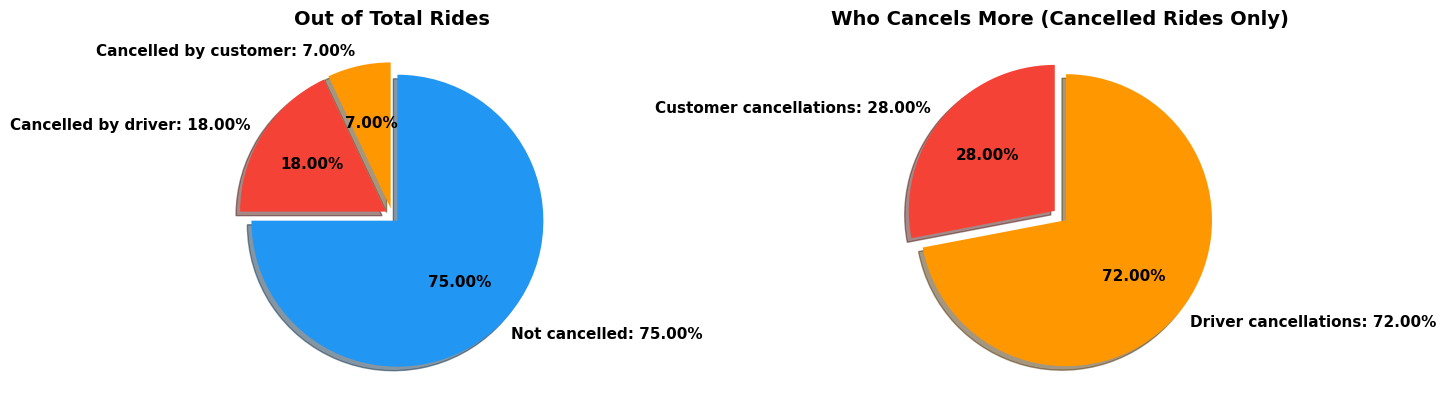

In [58]:
#Comparison chart
colors_total = ['#FF9800', '#F44336', '#2196F3'] 
colors_cancelled = ['#F44336', '#FF9800']
explode_total = (0.05, 0.05, 0.05)
explode_cancelled = (0.05, 0.05)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Out of TOTAL rides
wedges1, texts1, autotexts1 = axes[0].pie(
    [Rides_cancelled_by_customer, Rides_cancelled_by_driver, not_cancelled_dc],
    labels=[
        f"Cancelled by customer: {pct_cust_total:.2f}%",
        f"Cancelled by driver: {pct_drv_total:.2f}%",
        f"Not cancelled: {pct_not_total:.2f}%",
    ],
    autopct="%.2f%%",
    colors=colors_total,
    explode=explode_total,
    startangle=90,
    shadow=True
)
axes[0].set_title("Out of Total Rides", fontsize=14, weight='bold')

# Chart 2: Among CANCELLED rides only
wedges2, texts2, autotexts2 = axes[1].pie(
    [Rides_cancelled_by_customer, Rides_cancelled_by_driver],
    labels=[
        f"Customer cancellations: {pct_cust_cancel:.2f}%",
        f"Driver cancellations: {pct_drv_cancel:.2f}%"
    ],
    autopct="%.2f%%",
    colors=colors_cancelled,
    explode=explode_cancelled,
    startangle=90,
    shadow=True
)
axes[1].set_title("Who Cancels More (Cancelled Rides Only)", fontsize=14, weight='bold')

for texts in [texts1 + autotexts1, texts2 + autotexts2]:
    for text in texts:
        text.set_fontsize(11)
        text.set_weight('bold')

plt.tight_layout()
plt.show()


## Cancellation and Incompletes Rides Reason Analysis

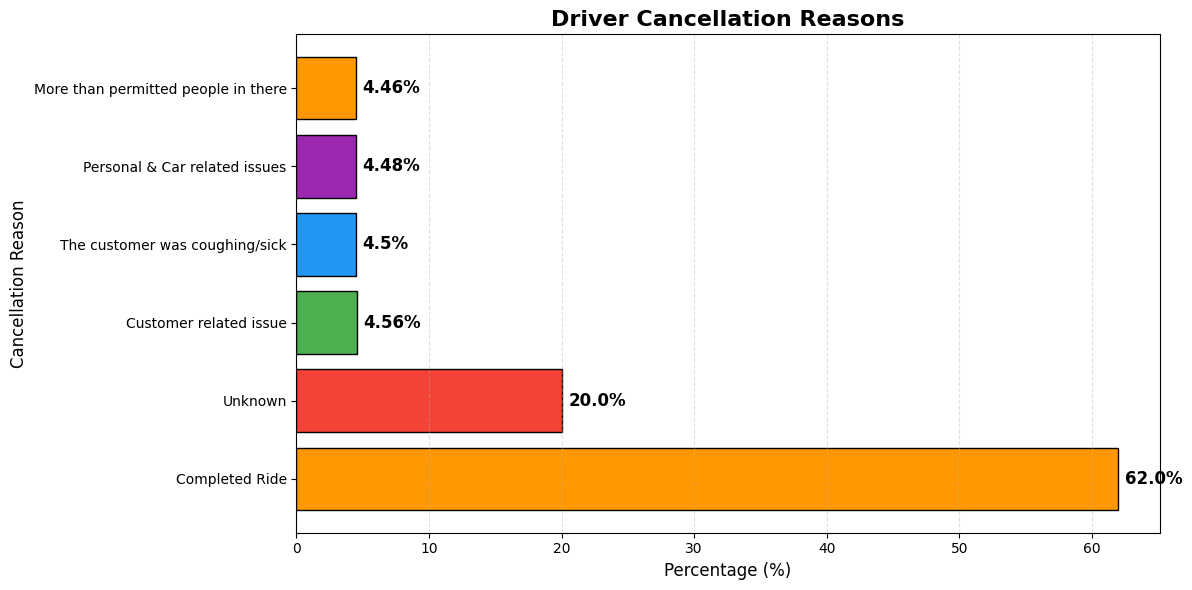

In [59]:
driver_reason = Uber_clean['Driver Cancellation Reason'].value_counts()
percent_driver_reason = (driver_reason / driver_reason.sum() * 100).round(2)


colors = ['#FF9800', '#F44336', '#4CAF50', '#2196F3', '#9C27B0'] 
colors = colors[:len(driver_reason)]  


plt.figure(figsize=(12,6))
bars = plt.barh(driver_reason.index, percent_driver_reason, color=colors, edgecolor='black')


for bar, pct in zip(bars, percent_driver_reason):
    plt.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f"{pct}%", va='center', fontsize=12, fontweight='bold')

plt.xlabel("Percentage (%)", fontsize=12)
plt.ylabel("Cancellation Reason", fontsize=12)
plt.title("Driver Cancellation Reasons", fontsize=16, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

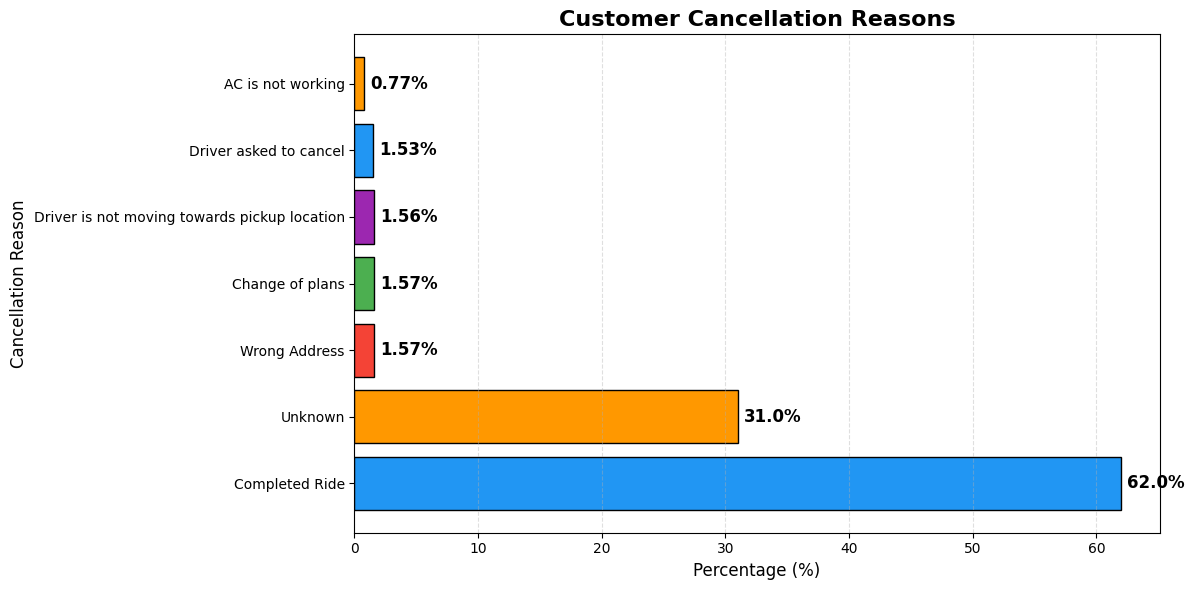

In [60]:
customer_reason = Uber_clean['Reason for cancelling by Customer'].value_counts()
percent_customer_reason = (customer_reason / customer_reason.sum() * 100).round(2)

colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50', '#9C27B0'] 
colors = colors[:len(customer_reason)]  
plt.figure(figsize=(12,6))
bars = plt.barh(customer_reason.index, percent_customer_reason, color=colors, edgecolor='black')

for bar, pct in zip(bars, percent_customer_reason):
    plt.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f"{pct}%", va='center', fontsize=12, fontweight='bold')

plt.xlabel("Percentage (%)", fontsize=12)
plt.ylabel("Cancellation Reason", fontsize=12)
plt.title("Customer Cancellation Reasons", fontsize=16, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

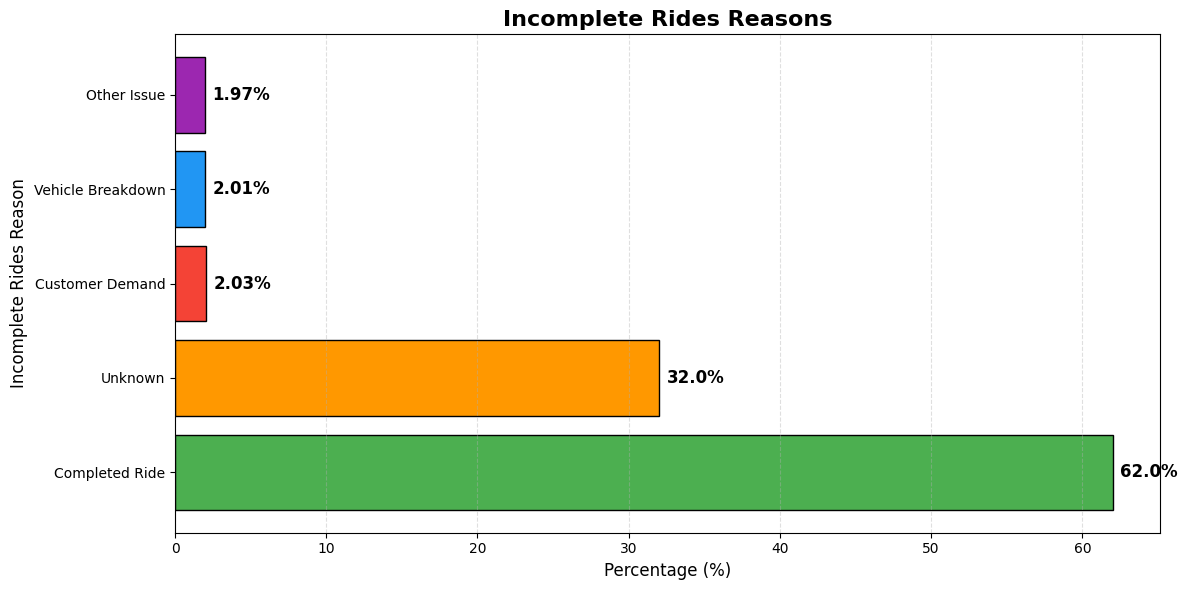

In [61]:
incomplete_rides_reason = Uber_clean['Incomplete Rides Reason'].value_counts()
percent_incomplete_rides = (incomplete_rides_reason / total_rides * 100).round(2)

colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3', '#9C27B0']
colors = colors[:len(incomplete_rides_reason)]

plt.figure(figsize=(12,6))
bars = plt.barh(incomplete_rides_reason.index, percent_incomplete_rides, color=colors, edgecolor='black')

for bar, pct in zip(bars, percent_incomplete_rides):
    plt.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f"{pct}%", va='center', fontsize=12, fontweight='bold')

plt.xlabel("Percentage (%)", fontsize=12)
plt.ylabel("Incomplete Rides Reason", fontsize=12)
plt.title("Incomplete Rides Reasons", fontsize=16, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

##  Vehicle Type Performance Analysis
### Vehicle Demand Analysis

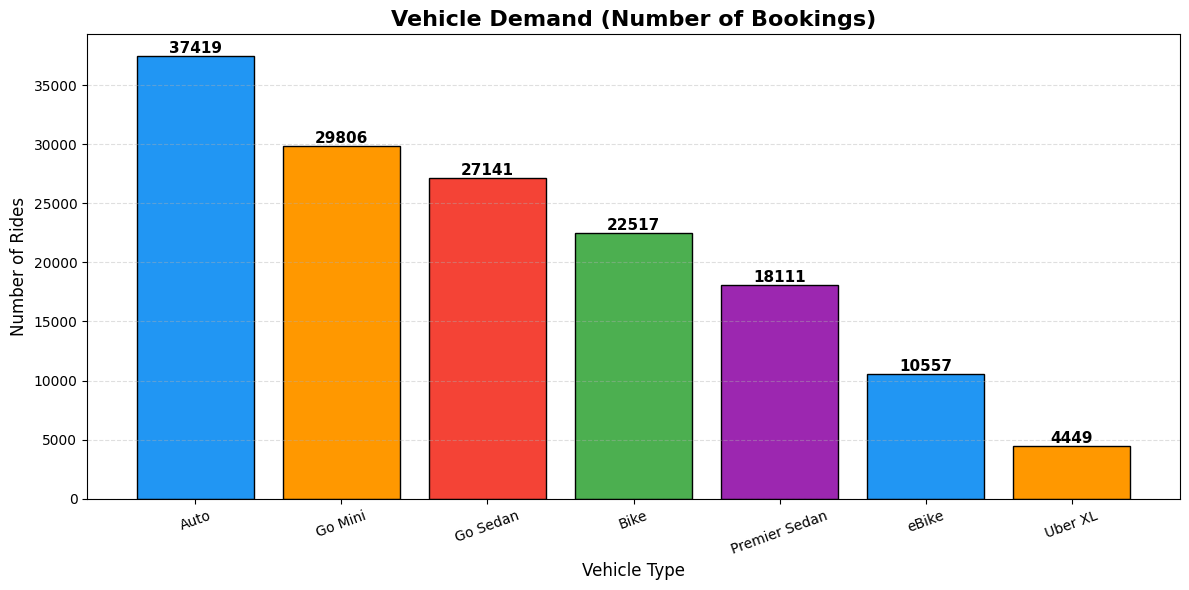

In [62]:
vehicle_counts = Uber_clean['Vehicle Type'].value_counts()


colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50', '#9C27B0'] 
colors = colors[:len(vehicle_counts)]

plt.figure(figsize=(12,6))
bars = plt.bar(vehicle_counts.index, vehicle_counts.values, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), ha='center', va='bottom', fontsize=11, fontweight='bold')


plt.title("Vehicle Demand (Number of Bookings)", fontsize=16, weight='bold')
plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Number of Rides", fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [63]:
## Average Price by Vehicle
Average_Price_Vehicle = Uber_clean.groupby("Vehicle Type")['Booking Value SAR'].mean().round(2)
print("\nAverage Price by Vehicle")
print(Average_Price_Vehicle)


Average Price by Vehicle
Vehicle Type
Auto             21.46
Bike             21.58
Go Mini          21.51
Go Sedan         21.59
Premier Sedan    21.55
Uber XL          21.33
eBike            21.38
Name: Booking Value SAR, dtype: float64


In [64]:
## Average Distance by Vehicle
Average_ride_distance_Vehicle = Uber_clean.groupby("Vehicle Type")['Ride Distance'].mean().round(2)
print("\nAverage Ride Distance by Vehicle")
print(Average_ride_distance_Vehicle)


Average Ride Distance by Vehicle
Vehicle Type
Auto             24.33
Bike             24.35
Go Mini          24.33
Go Sedan         24.32
Premier Sedan    24.32
Uber XL          24.19
eBike            24.58
Name: Ride Distance, dtype: float64


In [65]:
## Price per km
Uber_clean["per_km_charge"] = Uber_clean["Booking Value SAR"] / Uber_clean["Ride Distance"]
price_per_km_charge_by_vehicle = Uber_clean.groupby("Vehicle Type")["per_km_charge"].mean().round(2)
print("\nPrice per km by Vehicle Type")
print(price_per_km_charge_by_vehicle)


Price per km by Vehicle Type
Vehicle Type
Auto             1.42
Bike             1.42
Go Mini          1.41
Go Sedan         1.42
Premier Sedan    1.41
Uber XL          1.42
eBike            1.36
Name: per_km_charge, dtype: float64



Cancellation Rate by Vehicle Type (%)


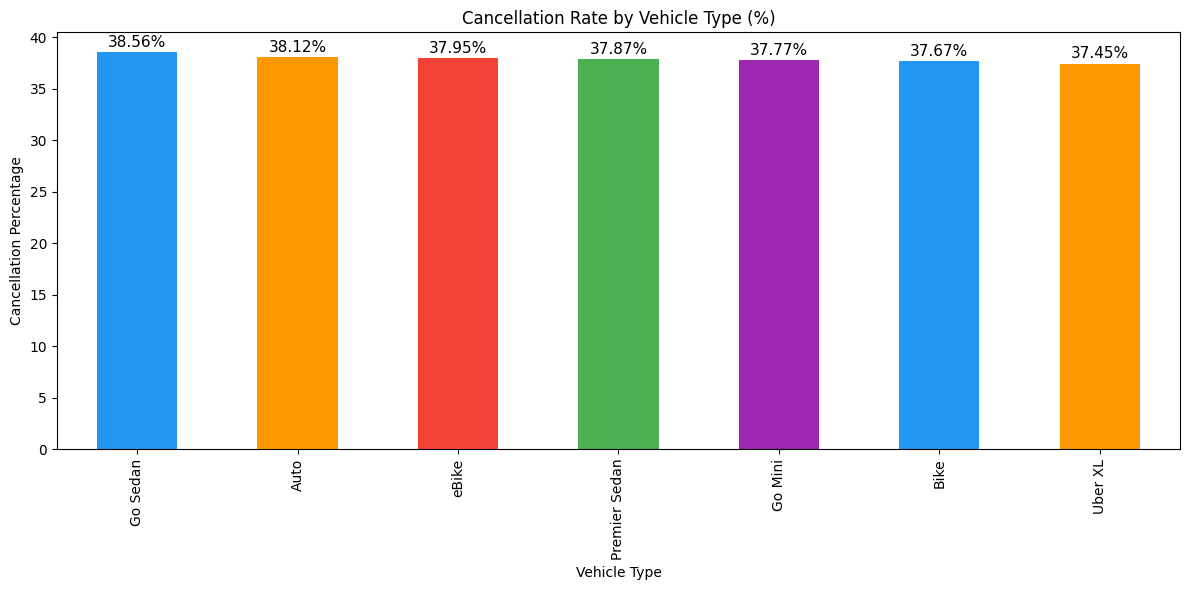

In [66]:
## Cancellation Rate by Vehicle
cancellation_rate_vehicle = (
    Uber_clean[Uber_clean['Booking Status'] != 'Completed']
    .groupby('Vehicle Type')['Booking ID'].count()
    /
    Uber_clean.groupby('Vehicle Type')['Booking ID'].count()
    * 100
).round(2)

print("\nCancellation Rate by Vehicle Type (%)")
plt.figure(figsize=(12,6))
ax = cancellation_rate_vehicle.sort_values(ascending=False).plot(
    kind='bar',
    color= ['#2196F3', '#FF9800', '#F44336', '#4CAF50', '#9C27B0']
)

for i, v in enumerate(cancellation_rate_vehicle.sort_values(ascending=False)):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontsize=11)

plt.title("Cancellation Rate by Vehicle Type (%)")
plt.ylabel("Cancellation Percentage")
plt.xlabel("Vehicle Type")
plt.tight_layout()
plt.show()

## Revenue Contribution by Vehicle

In [67]:
completed_rides = Uber_clean[Uber_clean['Booking Status'] == 'Completed']

sum_of_booking_vehicles = (
    completed_rides.groupby('Vehicle Type')['Booking Value']
        .sum()
        .sort_values(ascending=False) / 1_000_000
)

plt.figure(figsize=(12, 6))
bars = plt.bar(sum_of_booking_vehicles.index, sum_of_booking_vehicles.values, color=['#2196F3', '#FF9800', '#F44336', '#4CAF50', '#9C27B0'], edgecolor='black')


for i, v in enumerate(sum_of_booking_vehicles.values):
    plt.text(i, v + 0.05, f"{v:.2f}M", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Revenue (in Millions SAR)", fontsize=12)
plt.title("Revenue Generated by Vehicle Type (Completed Rides Only)", fontsize=14, weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: Booking Value'